# Day 0 Homework — One-State Code Explainer

**Time:** 30–45 minutes. Complete one checkpoint at a time. This problem is different from the tutorial.

## Checkpoint 1 — Connect to the model

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="http://127.0.0.1:5001/gateway/mlflow/v1",
    api_key="not-needed",
    model="workshop-gemini",
)
assert llm.invoke("Reply with ready").content

## Checkpoint 2 — Define state

Add `problem`, `code`, and `explanation` to `State`. Decide which fields exist before the node runs.

In [4]:
from typing import TypedDict

class State(TypedDict, total=False):
    problem: str
    code: str
    explanation: str

## Checkpoint 3 — Implement one node

The node should return only the field it updates. Test the node directly before building a graph.

In [5]:
def explain_code(state: State):
    prompt = f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}\n\nExplain what the code is trying to do and identify any bugs."
    return {"explanation": llm.invoke(prompt).content}

example = {
    "problem": "Return the first item in a non-empty list.",
    "code": "def first(items):\n    return items[1]",
}
assert explain_code(example)["explanation"].strip()

## Checkpoint 4 — Build the graph

Predict the path, then add `START → explain_code → END`.

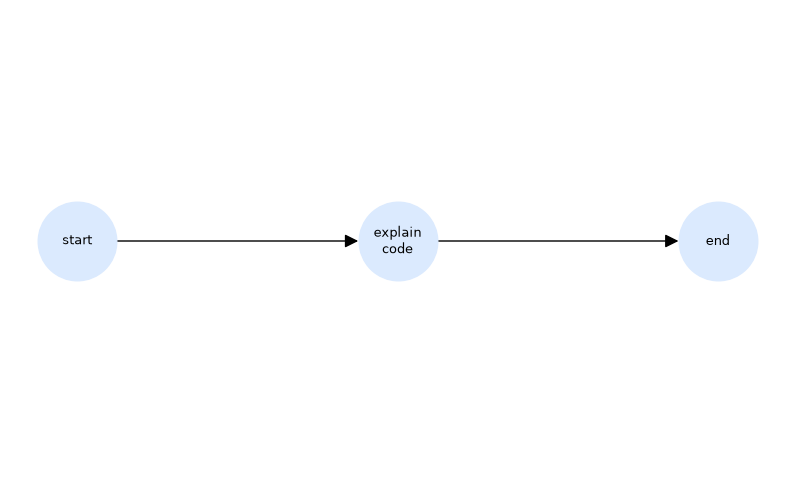

In [6]:
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

builder = StateGraph(State)
builder.add_node("explain_code", explain_code)
builder.add_edge(START, "explain_code")
builder.add_edge("explain_code", END)
graph = builder.compile()
show_graph(graph)

## Checkpoint 5 — Acceptance checks

Uncomment after compiling the graph. These checks verify structure and state, not exact model wording.

In [7]:
result = graph.invoke(example)
nodes = set(graph.get_graph().nodes) - {"__start__", "__end__"}
assert nodes == {"explain_code"}
assert result["problem"] == example["problem"]
assert result["code"] == example["code"]
assert result["explanation"].strip()
print(result["explanation"]); print("All checks passed")

The provided code intends to return the first item from a non-empty list. Here’s a breakdown of the code:

```python
def first(items):
    return items[1]
```

### Explanation:
- The function `first` takes a single argument `items`, which is expected to be a non-empty list.
- The code attempts to return the first item of that list using `items[1]`.

### Bug Identification:
There is a bug in the code. In Python, list indices start at `0`, not `1`. Therefore, `items[1]` actually accesses the second item of the list, not the first. 

### Correct Code:
To return the first item, the correct index should be `0`:

```python
def first(items):
    return items[0]
```

With this correction, the code will return the correct first item from the given list. 

### Summary:
- The code attempts to return the first item from a list but incorrectly uses `items[1]` instead of `items[0]`.
- Update the index to `0` to fix the bug and achieve the intended functionality.
All checks passed


## Reflection

In two sentences: what does state hold, and what does the node do? Then try the optional `possible_bug` output described in the README.